# 01 Developmental Tempo And Noise

Reads only from the centralized cache in `/Users/nick/Projects/data/morphseq/results/20260528`.


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from figure_utils import CACHE_DIR, FIG_DIR, set_light_style, savefig, temperature_scatter, add_identity, plot_heatmap_matrix
set_light_style()
print(CACHE_DIR)
print(FIG_DIR)


/Users/nick/Projects/data/morphseq/results/20260528
/Users/nick/Projects/data/morphseq/results/20260528/figures


In [2]:
joint = pd.read_csv(CACHE_DIR / 'joint_141_morph_seq.csv')
hf_morph = pd.read_csv(CACHE_DIR / 'hf_pca_morph_df_with_spline_distance.csv')
manifest = pd.read_csv(CACHE_DIR / 'source_manifest.csv')
print(joint.shape)
joint.head()


(141, 40)


,snip_id,temperature,timepoint,mdl_stage_hpf,pseudostage,PCA_00_bio_mean,PCA_00_bio_std,PCA_00_bio_count,PCA_01_bio_mean,PCA_01_bio_std,...,PCA_08_bio_std,PCA_08_bio_count,PCA_09_bio_mean,PCA_09_bio_std,PCA_09_bio_count,embryo_id,sample,morph_dist_spline,morph_branch_flag,nn_stage_hpf
0,20240813_24hpf_A02_e00_t0000,19.0,24.0,14.150698,20.234234,1.683267,0.184066,54,-0.270677,0.145115,...,0.072203,54,-0.035248,0.064520,54,20240813_24hpf_A02_e00_t0000,hotfish2_P05_A1,0.449615,False,14.490473
1,20240813_24hpf_A03_e00_t0000,25.0,24.0,16.678449,23.207207,1.981657,0.147383,42,-0.751075,0.135772,...,0.042360,42,-0.004364,0.037301,42,20240813_24hpf_A03_e00_t0000,hotfish2_P05_A2,0.579035,False,17.768315
2,20240813_24hpf_A04_e00_t0000,28.5,24.0,24.137157,25.819820,-0.734977,0.242611,45,-1.613671,0.158663,...,0.046099,45,-0.078740,0.036958,45,20240813_24hpf_A04_e00_t0000,hotfish2_P05_A3,0.232631,False,25.925120
3,20240813_24hpf_A05_e00_t0000,32.0,24.0,28.506869,29.153153,-1.722967,0.165611,43,-1.262145,0.251711,...,0.034053,43,0.051215,0.034167,43,20240813_24hpf_A05_e00_t0000,hotfish2_P05_A4,0.254436,False,29.388246
4,20240813_24hpf_A06_e00_t0000,33.5,24.0,24.187232,26.630631,-1.490460,0.193664,54,-1.388786,0.189838,...,0.048336,54,-0.005558,0.050310,54,20240813_24hpf_A06_e00_t0000,hotfish2_P05_A5,0.392497,False,25.039300


## 1.a Sequence-based stage predictions vs morphology-based stage predictions


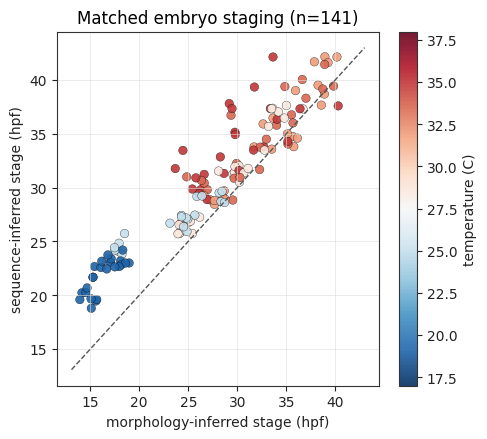

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
temperature_scatter(ax, joint['mdl_stage_hpf'], joint['pseudostage'], joint['temperature'], s=38, alpha=0.9)
add_identity(ax, joint['mdl_stage_hpf'], joint['pseudostage'])
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('sequence-inferred stage (hpf)')
ax.set_title('Matched embryo staging (n=141)')
savefig(fig, '01a_seq_vs_morph_stage')
plt.show()


## 1.b Staging variability comparison

Uses cohort-level standard deviations available from the old morphology and sequencing staging notebooks.


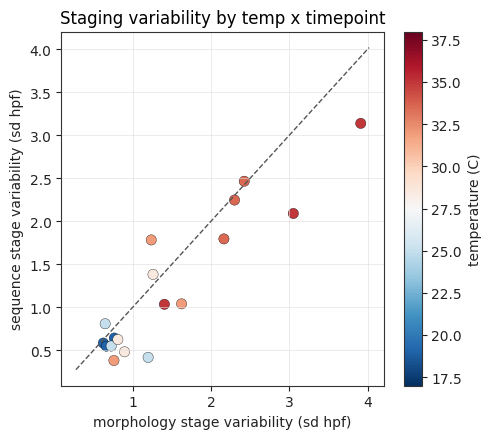

In [4]:
cohort = joint.groupby(['temperature', 'timepoint'], as_index=False).agg(
    morph_stage_mean=('mdl_stage_hpf', 'mean'),
    morph_stage_std=('mdl_stage_hpf', 'std'),
    seq_stage_mean=('pseudostage', 'mean'),
    seq_stage_std=('pseudostage', 'std'),
    n=('snip_id', 'count'),
)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
temperature_scatter(ax, cohort['morph_stage_std'], cohort['seq_stage_std'], cohort['temperature'], s=55)
add_identity(ax, cohort['morph_stage_std'], cohort['seq_stage_std'])
ax.set_xlabel('morphology stage variability (sd hpf)')
ax.set_ylabel('sequence stage variability (sd hpf)')
ax.set_title('Staging variability by temp x timepoint')
savefig(fig, '01b_staging_variability_comparison')
plt.show()
cohort.to_csv(CACHE_DIR / 'tempo_noise_cohort_summary.csv', index=False)


## 1.c Deviations from Arrhenius predictions

Uses the prior linear Arrhenius-style expectation used in old notebooks: `6 + (timepoint - 6) * (0.055 * temperature - 0.57)`.


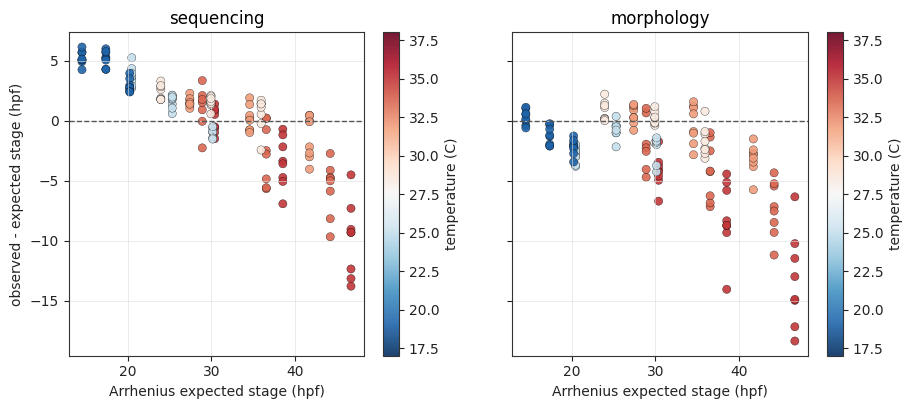

In [5]:
joint['arrhenius_expected_stage'] = 6 + (joint['timepoint'] - 6) * (0.055 * joint['temperature'] - 0.57)
joint['seq_arrhenius_dev'] = joint['pseudostage'] - joint['arrhenius_expected_stage']
joint['morph_arrhenius_dev'] = joint['mdl_stage_hpf'] - joint['arrhenius_expected_stage']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, y, title in zip(axes, ['seq_arrhenius_dev', 'morph_arrhenius_dev'], ['sequencing', 'morphology']):
    temperature_scatter(ax, joint['arrhenius_expected_stage'], joint[y], joint['temperature'], s=35, alpha=0.9)
    ax.axhline(0, color='#555555', lw=1, ls='--')
    ax.set_xlabel('Arrhenius expected stage (hpf)')
    ax.set_title(title)
axes[0].set_ylabel('observed - expected stage (hpf)')
savefig(fig, '01c_arrhenius_deviations_seq_morph')
plt.show()


## 1.d Morphological variability as a function of temperature and stage


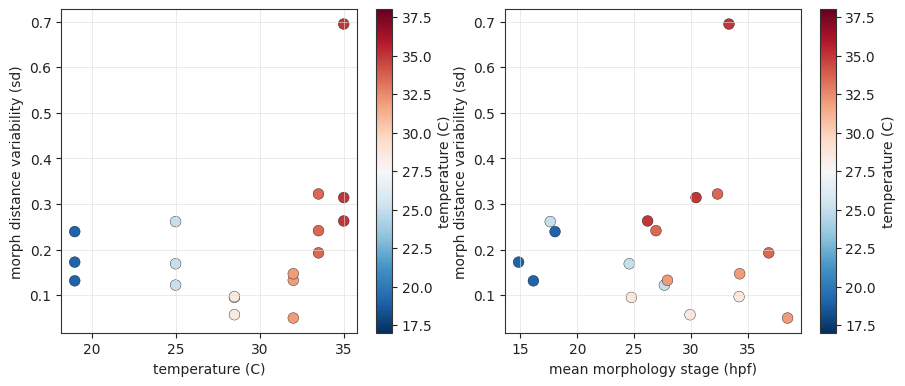

In [6]:
cohort_morph = hf_morph.groupby(['temperature', 'timepoint'], as_index=False).agg(
    morph_dist_spline_mean=('morph_dist_spline', 'mean'),
    morph_dist_spline_std=('morph_dist_spline', 'std'),
    morph_stage_mean=('mdl_stage_hpf', 'mean'),
    morph_stage_std=('mdl_stage_hpf', 'std'),
    n=('snip_id', 'count'),
)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
temperature_scatter(axes[0], cohort_morph['temperature'], cohort_morph['morph_dist_spline_std'], cohort_morph['temperature'], s=60)
axes[0].set_xlabel('temperature (C)')
axes[0].set_ylabel('morph distance variability (sd)')
temperature_scatter(axes[1], cohort_morph['morph_stage_mean'], cohort_morph['morph_dist_spline_std'], cohort_morph['temperature'], s=60)
axes[1].set_xlabel('mean morphology stage (hpf)')
axes[1].set_ylabel('morph distance variability (sd)')
savefig(fig, '01d_morph_variability_by_temperature_stage')
plt.show()
cohort_morph.to_csv(CACHE_DIR / 'morph_variability_cohort_summary.csv', index=False)
